In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from netket.hilbert import Spin
from netket.operator import Ising
from netket.graph import Hypercube
from scipy.sparse.linalg import eigsh

from rbmopt import RBM

∣NK⟩ Tip: You can load logged data with nk.utils.history.HistoryDict.from_file(data.log).

In [ ]:
N             = 12
J             = 1.0
n_hidden      = 20
n_epochs      = 3500
batch_size    = 100
learning_rate = 0.01
log_every     = 100
k_cd          = 5
dataset_size  = 5000

h_values = [0.25, 0.9, 1.0, 1.1, 1.2, 1.25, 1.3, 1.45, 1.75, 2.0]

In [3]:
graph = Hypercube(length=N, n_dim=1, pbc=True)
hi    = Spin(s=1/2, N=graph.n_nodes)

all_states = hi.all_states()

In [4]:
def get_ground_state(h):
    H = Ising(hilbert=hi, graph=graph, h=h, J=J)
    eigvals, eigvecs = eigsh(H.to_sparse(), k=1, which='SA')
    psi0     = eigvecs[:, 0]
    psi_prob = np.abs(psi0) ** 2
    psi_prob = psi_prob / psi_prob.sum()

    indices     = np.random.choice(len(all_states), size=dataset_size, p=psi_prob)
    dataset_pm  = all_states[indices]
    dataset_bin = ((dataset_pm + 1) / 2).astype(float)

    return psi_prob, dataset_bin

In [ ]:
results = {}

for h in h_values:
    ratio = h / J
    print(f"\n{'='*55}")
    print(f"  Entrenando RBM  |  h/J = {ratio:.2f}")
    print(f"{'='*55}")

    psi_prob, dataset_bin = get_ground_state(h)

    rbm = RBM(n_visible=N, n_hidden=n_hidden)

    kl_history = rbm.train(
        dataset       = dataset_bin,
        n_epochs      = n_epochs,
        batch_size    = batch_size,
        learning_rate = learning_rate,
        k             = k_cd,
        log_every     = log_every,
        kl_mode       = 'exact',
        psi_prob      = psi_prob,
        hi_states     = all_states,
    )

    results[ratio] = kl_history

    for epoch, kl in kl_history:
        print(f"  Época {epoch:5d} | KL = {kl:.6f}")

    epochs_arr = np.array([e for e, _ in kl_history])
    kl_arr     = np.array([k for _, k in kl_history])
    np.savetxt(f"kl_hJ{ratio:.2f}.txt",
               np.column_stack([epochs_arr, kl_arr]),
               header="epoch  KL", fmt=["%.0f", "%.8f"])


  Entrenando RBM  |  h/J = 0.25
  Época     0 | KL = 7.312177
  Época   100 | KL = 7.311057
  Época   200 | KL = 7.305812
  Época   300 | KL = 7.285299
  Época   400 | KL = 7.211660
  Época   500 | KL = 6.948655
  Época   600 | KL = 6.112379
  Época   700 | KL = 4.144836
  Época   800 | KL = 1.857535
  Época   900 | KL = 0.858432
  Época  1000 | KL = 0.508393
  Época  1100 | KL = 0.347537
  Época  1200 | KL = 0.257711
  Época  1300 | KL = 0.204264
  Época  1400 | KL = 0.172727
  Época  1500 | KL = 0.144606
  Época  1600 | KL = 0.131960
  Época  1700 | KL = 0.112354
  Época  1800 | KL = 0.099445
  Época  1900 | KL = 0.089874
  Época  2000 | KL = 0.080235
  Época  2100 | KL = 0.077532
  Época  2200 | KL = 0.074344
  Época  2300 | KL = 0.073915
  Época  2400 | KL = 0.081039
  Época  2500 | KL = 0.080310
  Época  2600 | KL = 0.074205
  Época  2700 | KL = 0.073972
  Época  2800 | KL = 0.073344
  Época  2900 | KL = 0.078093
  Época  3000 | KL = 0.072549
  Época  3100 | KL = 0.065603
  Época

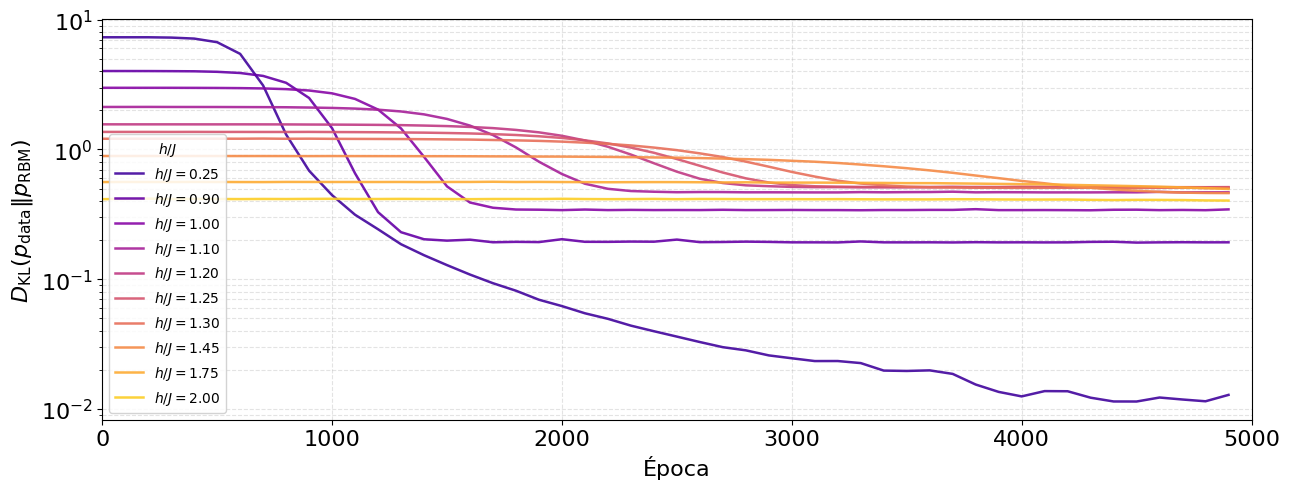


Gráfica guardada en kl_vs_epochs_TFIM.png


In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

ratios = sorted(results.keys())
colors = cm.plasma(np.linspace(0.1, 0.9, len(ratios)))

for ratio, color in zip(ratios, colors):
    history = results[ratio]
    epochs  = [e for e, _ in history]
    kls     = [k for _, k in history]
    ax.plot(epochs, kls,
            label=f"$h/J = {ratio:.2f}$",
            color=color, linewidth=1.8, alpha=0.9)

ax.set_xlabel("Época", fontsize=16)
ax.set_ylabel(r"$DKL(p_{\mathrm{data}} \| p_{\mathrm{RBM}})$", fontsize=16)
ax.set_yscale("log")
ax.legend(fontsize=10, loc="lower left", framealpha=0.85,
          title="$h/J$", title_fontsize=10)
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.set_xlim(0, n_epochs)
ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.savefig("kl_vs_epochs_TFIM.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGráfica guardada en kl_vs_epochs_TFIM.png")